In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report

print("Setup OK")


Setup OK


In [4]:
train_path = "../data/adult.data"
test_path  = "../data/adult.test"

columns = [
    "age", "workclass", "fnlwgt", "education", "education-num", "marital-status",
    "occupation", "relationship", "race", "sex", "capital-gain", "capital-loss",
    "hours-per-week", "native-country", "income"
]

train_df = pd.read_csv(train_path, names=columns, sep=",\s*", engine='python')
test_df  = pd.read_csv(test_path, names=columns, sep=",\s*", engine='python', skiprows=1)

print("Train shape:", train_df.shape)
print("Test shape :", test_df.shape)
train_df.head()


Train shape: (32561, 15)
Test shape : (16281, 15)


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [5]:
# =========================
# 1. Cek missing values
# =========================
print("Missing values per kolom (Train):")
print(train_df.isnull().sum())
print("\nMissing values per kolom (Test):")
print(test_df.isnull().sum())

Missing values per kolom (Train):
age               0
workclass         0
fnlwgt            0
education         0
education-num     0
marital-status    0
occupation        0
relationship      0
race              0
sex               0
capital-gain      0
capital-loss      0
hours-per-week    0
native-country    0
income            0
dtype: int64

Missing values per kolom (Test):
age               0
workclass         0
fnlwgt            0
education         0
education-num     0
marital-status    0
occupation        0
relationship      0
race              0
sex               0
capital-gain      0
capital-loss      0
hours-per-week    0
native-country    0
income            0
dtype: int64


In [6]:
# =========================
# 2. Cek duplikat
# =========================
print("\nJumlah duplikat di Train:", train_df.duplicated().sum())
print("Jumlah duplikat di Test :", test_df.duplicated().sum())


Jumlah duplikat di Train: 24
Jumlah duplikat di Test : 5


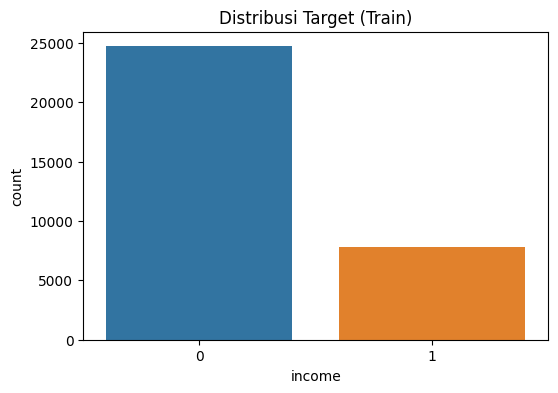

In [44]:
import os
import matplotlib.pyplot as plt
import seaborn as sns

# Folder images sejajar dengan notebook
parent_dir = os.path.dirname(os.getcwd())
images_path = os.path.join(parent_dir, 'images')
os.makedirs(images_path, exist_ok=True)

# =========================
# 3. Cek distribusi target
# =========================
plt.figure(figsize=(6,4))
sns.countplot(x="income", data=train_df)
plt.title("Distribusi Target (Train)")

# Simpan ke folder images
plt.savefig(os.path.join(images_path, "distribusi_target_train.png"))

plt.show()


In [8]:
# =========================
# 4. Pisahkan fitur numerik dan kategorikal
# =========================
numeric_features = ["age", "fnlwgt", "education-num", "capital-gain", "capital-loss", "hours-per-week"]
categorical_features = [col for col in train_df.columns if col not in numeric_features + ["income"]]

print("Numeric Features:", numeric_features)
print("Categorical Features:", categorical_features)

Numeric Features: ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']
Categorical Features: ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country']


In [9]:
# =========================
# 5. Definisikan preprocessing pipeline
# =========================
numeric_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(handle_unknown='ignore')

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

In [10]:
# =========================
# 6. Pisahkan X dan y
# =========================
X_train = train_df.drop("income", axis=1)
y_train = train_df["income"].apply(lambda x: 1 if x.strip() == ">50K" else 0)

X_test  = test_df.drop("income", axis=1)
y_test  = test_df["income"].apply(lambda x: 1 if x.strip().replace(".","") == ">50K" else 0)

print("\nSample target encoding (Train):")
print(y_train.value_counts())


Sample target encoding (Train):
income
0    24720
1     7841
Name: count, dtype: int64


In [11]:
# =========================
# 7. Terapkan preprocessing pada training dan test
# =========================
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed  = preprocessor.transform(X_test)

print("\nProcessed feature shape (Train):", X_train_processed.shape)
print("Processed feature shape (Test) :", X_test_processed.shape)


Processed feature shape (Train): (32561, 108)
Processed feature shape (Test) : (16281, 108)


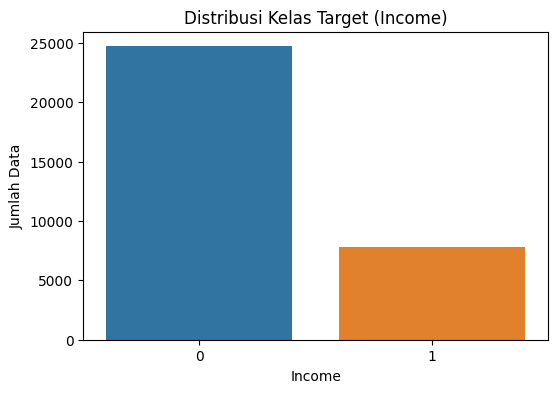

In [45]:

# Pastikan folder images ada
parent_dir = os.path.dirname(os.getcwd())
images_path = os.path.join(parent_dir, 'images')
os.makedirs(images_path, exist_ok=True)

plt.figure(figsize=(6,4))
sns.countplot(data=train_df, x='income')
plt.title('Distribusi Kelas Target (Income)')
plt.xlabel('Income')
plt.ylabel('Jumlah Data')

# Simpan ke folder images
plt.savefig(os.path.join(images_path, "distribusi_kelas_income.png"))

plt.show()

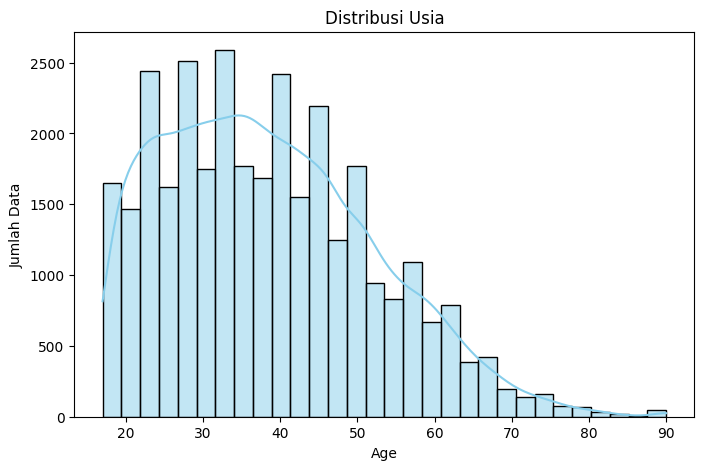

In [47]:
parent_dir = os.path.dirname(os.getcwd())
images_path = os.path.join(parent_dir, 'images')
os.makedirs(images_path, exist_ok=True)

plt.figure(figsize=(8,5))
sns.histplot(train_df['age'], bins=30, kde=True, color='skyblue')
plt.title('Distribusi Usia')
plt.xlabel('Age')
plt.ylabel('Jumlah Data')

# Simpan ke folder images
plt.savefig(os.path.join(images_path, "distribusi_usia.png"))

plt.show()

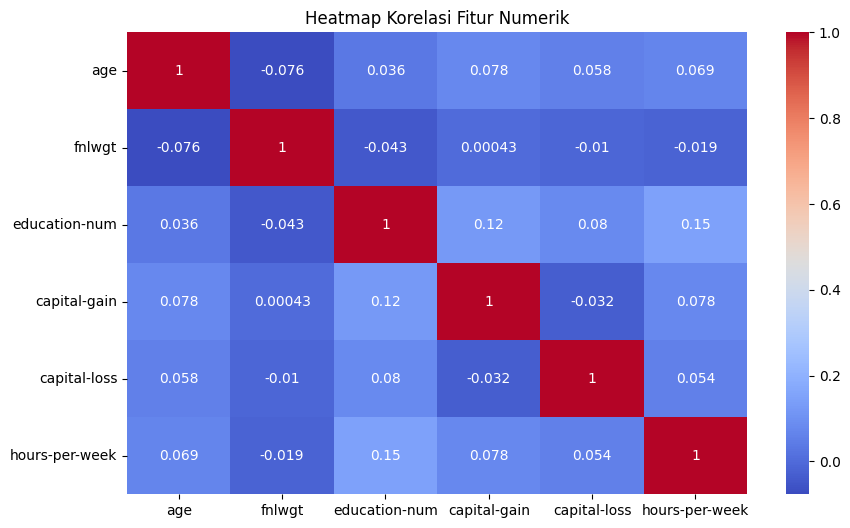

In [48]:
parent_dir = os.path.dirname(os.getcwd())
images_path = os.path.join(parent_dir, 'images')
os.makedirs(images_path, exist_ok=True)

numeric_features = ["age", "fnlwgt", "education-num", "capital-gain", "capital-loss", "hours-per-week"]

plt.figure(figsize=(10,6))
sns.heatmap(train_df[numeric_features].corr(), annot=True, cmap='coolwarm')
plt.title('Heatmap Korelasi Fitur Numerik')

# Simpan ke folder images
plt.savefig(os.path.join(images_path, "heatmap_korelasi_numerik.png"))

plt.show()

In [15]:
# -------------------------------
# 5.1 Data Cleaning
# -------------------------------

# Load dataset
train_path = "../data/adult.data"
test_path  = "../data/adult.test"

columns = [
    "age", "workclass", "fnlwgt", "education", "education-num", "marital-status",
    "occupation", "relationship", "race", "sex", "capital-gain", "capital-loss",
    "hours-per-week", "native-country", "income"
]

train_df = pd.read_csv(train_path, names=columns, sep=",\s*", engine='python')
test_df  = pd.read_csv(test_path, names=columns, sep=",\s*", engine='python', skiprows=1)

# Cek missing values
print("Missing values per kolom (train):")
print(train_df.isnull().sum())

print("\nMissing values per kolom (test):")
print(test_df.isnull().sum())

# Hapus duplikat
train_df = train_df.drop_duplicates()
test_df  = test_df.drop_duplicates()

# Konversi target menjadi 0/1
train_df['income'] = train_df['income'].apply(lambda x: 1 if '>50K' in x else 0)
test_df['income']  = test_df['income'].apply(lambda x: 1 if '>50K' in x else 0)

Missing values per kolom (train):
age               0
workclass         0
fnlwgt            0
education         0
education-num     0
marital-status    0
occupation        0
relationship      0
race              0
sex               0
capital-gain      0
capital-loss      0
hours-per-week    0
native-country    0
income            0
dtype: int64

Missing values per kolom (test):
age               0
workclass         0
fnlwgt            0
education         0
education-num     0
marital-status    0
occupation        0
relationship      0
race              0
sex               0
capital-gain      0
capital-loss      0
hours-per-week    0
native-country    0
income            0
dtype: int64


In [16]:
# -------------------------------
# 5.2 Feature Engineering
# -------------------------------

# Contoh: buat fitur baru "capital-net" (capital-gain - capital-loss)
train_df['capital-net'] = train_df['capital-gain'] - train_df['capital-loss']
test_df['capital-net']  = test_df['capital-gain'] - test_df['capital-loss']

In [17]:
# -------------------------------
# 5.3 Data Transformation
# -------------------------------

# Pisahkan fitur numerik dan kategorikal
numeric_features = ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week', 'capital-net']
categorical_features = ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country']

# Buat pipeline preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)

In [18]:
# -------------------------------
# 5.4 Data Splitting
# -------------------------------

# Pisahkan fitur dan target
X = train_df.drop('income', axis=1)
y = train_df['income']

# Stratified split untuk train/validation
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print("Train shape:", X_train.shape)
print("Validation shape:", X_val.shape)

Train shape: (26029, 15)
Validation shape: (6508, 15)


In [19]:
# ================================
# 5.5 Data Balancing (jika diperlukan)
# ================================

from imblearn.over_sampling import SMOTE
import pandas as pd
import numpy as np

# Transform semua fitur menjadi numerik (fit preprocessor pada training data)
X_train_transformed = preprocessor.fit_transform(X_train)
X_val_transformed   = preprocessor.transform(X_val)

# Cek distribusi kelas sebelum balancing
print("Distribusi kelas sebelum balancing:")
print(y_train.value_counts())

# Terapkan SMOTE untuk membuat kelas target seimbang
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train_transformed, y_train)

# Cek distribusi kelas setelah balancing
print("\nDistribusi kelas setelah balancing:")
print(pd.Series(y_train_bal).value_counts())

Distribusi kelas sebelum balancing:
income
0    19758
1     6271
Name: count, dtype: int64

Distribusi kelas setelah balancing:
income
0    19758
1    19758
Name: count, dtype: int64


In [20]:
# ================================
# 5.6 Ringkasan Data Preparation
# ================================

print("\n=== Ringkasan Data Preparation ===\n")

# 5.1 Data Cleaning
print("Data Cleaning:")
print("- Menghapus duplikat")
print("- Mengubah target 'income' menjadi numerik 0/1")
print("- Cek missing values (tidak ada yang signifikan)")
print("Mengapa penting: membersihkan data memastikan model belajar dari data yang valid.")
print("Bagaimana: drop_duplicates(), apply lambda pada target.\n")

# 5.2 Feature Engineering
print("Feature Engineering:")
print("- Membuat fitur baru 'capital-net' = capital-gain - capital-loss")
print("Mengapa penting: memberi informasi tambahan yang bisa membantu model.")
print("Bagaimana: train_df['capital-net'] = train_df['capital-gain'] - train_df['capital-loss']\n")

# 5.3 Data Transformation
print("Data Transformation:")
print("- Scaling numerik dengan StandardScaler")
print("- One-Hot Encoding fitur kategorikal")
print("Mengapa penting: model ML bekerja lebih baik dengan fitur numerik yang distandarisasi dan encoding.")
print("Bagaimana: ColumnTransformer dengan StandardScaler + OneHotEncoder\n")

# 5.4 Data Splitting
print("Data Splitting:")
print("- Training set 80%, Validation set 20%, stratified split untuk pertahankan distribusi kelas")
print("Mengapa penting: evaluasi model pada data yang tidak dilihat saat training.")
print("Bagaimana: train_test_split(..., stratify=y, random_state=42)\n")

# 5.5 Data Balancing
print("Data Balancing:")
print("- SMOTE applied pada training set untuk menyamakan jumlah kelas 0 dan 1")
print("Mengapa penting: mengurangi bias model terhadap kelas mayoritas")
print("Bagaimana: smote.fit_resample(X_train_transformed, y_train)")


=== Ringkasan Data Preparation ===

Data Cleaning:
- Menghapus duplikat
- Mengubah target 'income' menjadi numerik 0/1
- Cek missing values (tidak ada yang signifikan)
Mengapa penting: membersihkan data memastikan model belajar dari data yang valid.
Bagaimana: drop_duplicates(), apply lambda pada target.

Feature Engineering:
- Membuat fitur baru 'capital-net' = capital-gain - capital-loss
Mengapa penting: memberi informasi tambahan yang bisa membantu model.
Bagaimana: train_df['capital-net'] = train_df['capital-gain'] - train_df['capital-loss']

Data Transformation:
- Scaling numerik dengan StandardScaler
- One-Hot Encoding fitur kategorikal
Mengapa penting: model ML bekerja lebih baik dengan fitur numerik yang distandarisasi dan encoding.
Bagaimana: ColumnTransformer dengan StandardScaler + OneHotEncoder

Data Splitting:
- Training set 80%, Validation set 20%, stratified split untuk pertahankan distribusi kelas
Mengapa penting: evaluasi model pada data yang tidak dilihat saat traini

D:\golang\project-ml\.venv\lib\site-packages\sklearn\linear_model\_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Training Time: 0.338126 s
Inference Time: 0.000714 s
=== BASELINE MODEL METRICS ===
Accuracy : 0.8155
Precision: 0.5787
Recall   : 0.8610
F1-Score : 0.6921

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.80      0.87      4940
           1       0.58      0.86      0.69      1568

    accuracy                           0.82      6508
   macro avg       0.76      0.83      0.78      6508
weighted avg       0.86      0.82      0.83      6508



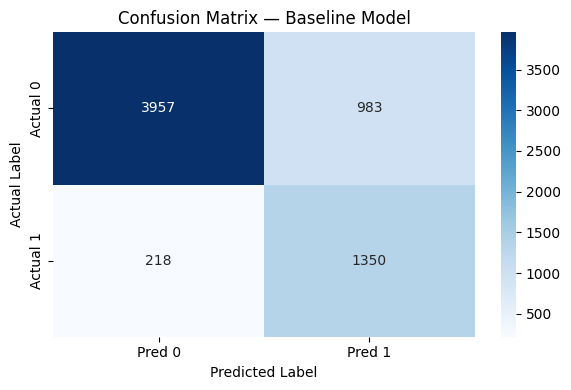

Model berhasil disimpan di: D:\golang\project-ml\models\logistic_regression_model.joblib


In [39]:
# ===============================
# BASELINE MODEL — LOGISTIC REGRESSION
# ===============================

import numpy as np
import time
import os
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)
import joblib  # untuk menyimpan model sklearn

# Pastikan folder images dan models ada (sejajar dengan folder notebooks)
parent_dir = os.path.dirname(os.getcwd())  # folder di atas notebook
images_path = os.path.join(parent_dir, 'images')
models_path = os.path.join(parent_dir, 'models')
os.makedirs(images_path, exist_ok=True)
os.makedirs(models_path, exist_ok=True)

# 1. TRANSFORMASI DATA
X_train_transformed = preprocessor.fit_transform(X_train)
X_val_transformed   = preprocessor.transform(X_val)

# 2. BALANCING DATA (SMOTE)
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(
    X_train_transformed, y_train
)

# 3. TRAIN BASELINE MODEL & HITUNG TRAINING TIME
model_baseline = LogisticRegression(
    C=1.0,
    solver='lbfgs',
    max_iter=100
)

start_train = time.perf_counter()
model_baseline.fit(X_train_bal, y_train_bal)
end_train = time.perf_counter()
training_time = end_train - start_train
print(f"Training Time: {training_time:.6f} s")

# 4. PREDIKSI & HITUNG INFERENCE TIME
start_inf = time.perf_counter()
y_pred_baseline = model_baseline.predict(X_val_transformed)
end_inf = time.perf_counter()
inference_time = end_inf - start_inf
print(f"Inference Time: {inference_time:.6f} s")

# 5. METRIK EVALUASI
accuracy  = accuracy_score(y_val, y_pred_baseline)
precision = precision_score(y_val, y_pred_baseline)
recall    = recall_score(y_val, y_pred_baseline)
f1        = f1_score(y_val, y_pred_baseline)

print("=== BASELINE MODEL METRICS ===")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-Score : {f1:.4f}\n")

print("Classification Report:")
print(classification_report(y_val, y_pred_baseline))

# 6. CONFUSION MATRIX VISUALISASI & SIMPAN
cm = confusion_matrix(y_val, y_pred_baseline)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Pred 0', 'Pred 1'],
    yticklabels=['Actual 0', 'Actual 1']
)
plt.title("Confusion Matrix — Baseline Model")
plt.ylabel("Actual Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.savefig(os.path.join(images_path, "confusion_matrix_baseline.png"))
plt.show()

# 7. SIMPAN MODEL
model_file = os.path.join(models_path, "logistic_regression_model.joblib")
joblib.dump(model_baseline, model_file)
print(f"Model berhasil disimpan di: {model_file}")


Training Time: 6.180661 s
Inference Time: 0.056805 s
=== RANDOM FOREST METRICS ===
Accuracy : 0.8084
Precision: 0.5660
Recall   : 0.8776
F1-Score : 0.6882

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.79      0.86      4940
           1       0.57      0.88      0.69      1568

    accuracy                           0.81      6508
   macro avg       0.76      0.83      0.77      6508
weighted avg       0.86      0.81      0.82      6508



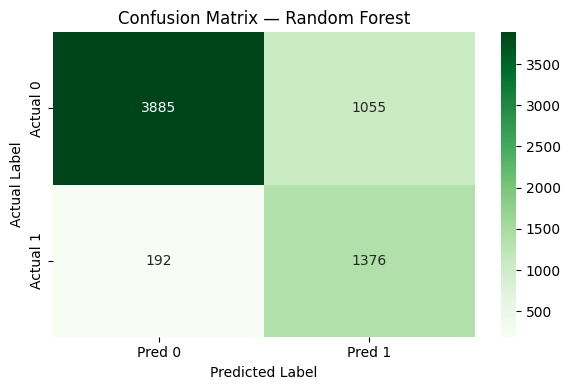

Model berhasil disimpan di: D:\golang\project-ml\models\random_forest_model.joblib


In [38]:
# ===============================
# MODEL 2 — RANDOM FOREST
# ===============================

import time
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)
import joblib  # untuk menyimpan model sklearn

# Pastikan folder images dan models ada (sejajar dengan folder notebooks)
parent_dir = os.path.dirname(os.getcwd())  # folder di atas notebook
images_path = os.path.join(parent_dir, 'images')
models_path = os.path.join(parent_dir, 'models')
os.makedirs(images_path, exist_ok=True)
os.makedirs(models_path, exist_ok=True)

# 1. INISIALISASI MODEL
model_advanced = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42
)

# 2. TRAINING MODEL & HITUNG TRAINING TIME
start_train = time.perf_counter()
model_advanced.fit(X_train_bal, y_train_bal)
end_train = time.perf_counter()
training_time = end_train - start_train
print(f"Training Time: {training_time:.6f} s")

# 3. PREDIKSI & HITUNG INFERENCE TIME
start_inf = time.perf_counter()
y_pred_advanced = model_advanced.predict(X_val_transformed)
end_inf = time.perf_counter()
inference_time = end_inf - start_inf
print(f"Inference Time: {inference_time:.6f} s")

# 4. METRIK EVALUASI
accuracy  = accuracy_score(y_val, y_pred_advanced)
precision = precision_score(y_val, y_pred_advanced)
recall    = recall_score(y_val, y_pred_advanced)
f1        = f1_score(y_val, y_pred_advanced)

print("=== RANDOM FOREST METRICS ===")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-Score : {f1:.4f}\n")

print("Classification Report:")
print(classification_report(y_val, y_pred_advanced))

# 5. CONFUSION MATRIX VISUALISASI & SIMPAN
cm = confusion_matrix(y_val, y_pred_advanced)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=['Pred 0', 'Pred 1'],
    yticklabels=['Actual 0', 'Actual 1']
)
plt.title("Confusion Matrix — Random Forest")
plt.ylabel("Actual Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.savefig(os.path.join(images_path, "confusion_matrix_random_forest.png"))
plt.show()

# 6. SIMPAN MODEL RANDOM FOREST
model_file = os.path.join(models_path, "random_forest_model.joblib")
joblib.dump(model_advanced, model_file)
print(f"Model berhasil disimpan di: {model_file}")


Epoch 1/50
1235/1235 [==============================] - 3s 2ms/step - loss: 0.3815 - accuracy: 0.8245 - val_loss: 0.3773 - val_accuracy: 0.8096
Epoch 2/50
1235/1235 [==============================] - 2s 2ms/step - loss: 0.3526 - accuracy: 0.8394 - val_loss: 0.3634 - val_accuracy: 0.8211
Epoch 3/50
1235/1235 [==============================] - 2s 2ms/step - loss: 0.3440 - accuracy: 0.8445 - val_loss: 0.3610 - val_accuracy: 0.8241
Epoch 4/50
1235/1235 [==============================] - 2s 2ms/step - loss: 0.3353 - accuracy: 0.8498 - val_loss: 0.3734 - val_accuracy: 0.8145
Epoch 5/50
1235/1235 [==============================] - 2s 2ms/step - loss: 0.3250 - accuracy: 0.8518 - val_loss: 0.3720 - val_accuracy: 0.8145
Epoch 6/50
1235/1235 [==============================] - 2s 2ms/step - loss: 0.3194 - accuracy: 0.8577 - val_loss: 0.3551 - val_accuracy: 0.8276
Epoch 7/50
1235/1235 [==============================] - 2s 2ms/step - loss: 0.3130 - accuracy: 0.8593 - val_loss: 0.3656 - val_accuracy:

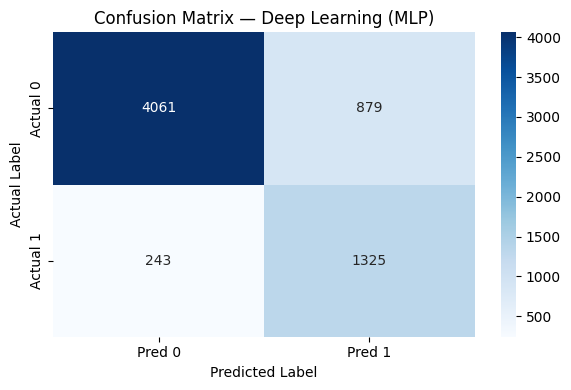

Model berhasil disimpan di: D:\golang\project-ml\models\mlp_model.h5


D:\golang\project-ml\.venv\lib\site-packages\keras\src\engine\training.py:3079: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [37]:
# ===============================
# MODEL 3 — DEEP LEARNING (MLP)
# ===============================

import numpy as np
import time
import os
from imblearn.over_sampling import SMOTE
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Pastikan folder images ada (sejajar dengan folder notebooks)
parent_dir = os.path.dirname(os.getcwd())
images_path = os.path.join(parent_dir, 'images')
os.makedirs(images_path, exist_ok=True)

# Tambahkan folder models
models_path = os.path.join(parent_dir, 'models')
os.makedirs(models_path, exist_ok=True)

# 1. TRANSFORM DATA (TABULAR → NUMERIK)
X_train_transformed = preprocessor.fit_transform(X_train)
X_val_transformed   = preprocessor.transform(X_val)

# 2. BALANCING DATA (SMOTE — TRAIN ONLY)
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(
    X_train_transformed, y_train
)

# 3. PREPARATION FOR DEEP LEARNING
X_train_dl = X_train_bal.toarray()
X_val_dl   = X_val_transformed.toarray()

y_train_dl = to_categorical(y_train_bal, num_classes=2)
y_val_dl   = to_categorical(y_val, num_classes=2)

input_dim = X_train_dl.shape[1]

# 4. BUILD MLP MODEL
model_dl = Sequential([
    Dense(128, activation='relu', input_shape=(input_dim,)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(2, activation='softmax')
])

model_dl.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# 5. TRAINING & HITUNG TRAINING TIME
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

start_train = time.perf_counter()
history = model_dl.fit(
    X_train_dl,
    y_train_dl,
    validation_data=(X_val_dl, y_val_dl),
    epochs=50,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)
end_train = time.perf_counter()
training_time = end_train - start_train
print(f"Training Time: {training_time:.6f} s")

# 6. EVALUATION & HITUNG INFERENCE TIME
start_inf = time.perf_counter()
y_pred_dl = model_dl.predict(X_val_dl)
end_inf = time.perf_counter()
inference_time = end_inf - start_inf
print(f"Inference Time: {inference_time:.6f} s")

y_pred_dl_classes = np.argmax(y_pred_dl, axis=1)

print("Accuracy Deep Learning:", accuracy_score(y_val, y_pred_dl_classes))
print(classification_report(y_val, y_pred_dl_classes))

# 7. MODEL SUMMARY
model_dl.summary()

# ===============================
# METRIK EVALUASI (MODEL 3)
# ===============================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

accuracy  = accuracy_score(y_val, y_pred_dl_classes)
precision = precision_score(y_val, y_pred_dl_classes)
recall    = recall_score(y_val, y_pred_dl_classes)
f1        = f1_score(y_val, y_pred_dl_classes)

print("=== DEEP LEARNING (MLP) METRICS ===")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-Score : {f1:.4f}\n")

print("Classification Report:")
print(classification_report(y_val, y_pred_dl_classes))

# ===============================
# CONFUSION MATRIX VISUALIZATION & SIMPAN
# ===============================

cm = confusion_matrix(y_val, y_pred_dl_classes)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Pred 0', 'Pred 1'],
    yticklabels=['Actual 0', 'Actual 1']
)
plt.title("Confusion Matrix — Deep Learning (MLP)")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.tight_layout()
plt.savefig(os.path.join(images_path, "confusion_matrix_mlp.png"))
plt.show()

# ===============================
# SIMPAN MODEL
# ===============================
model_dl.save(os.path.join(models_path, "mlp_model.h5"))
print(f"Model berhasil disimpan di: {os.path.join(models_path, 'mlp_model.h5')}")


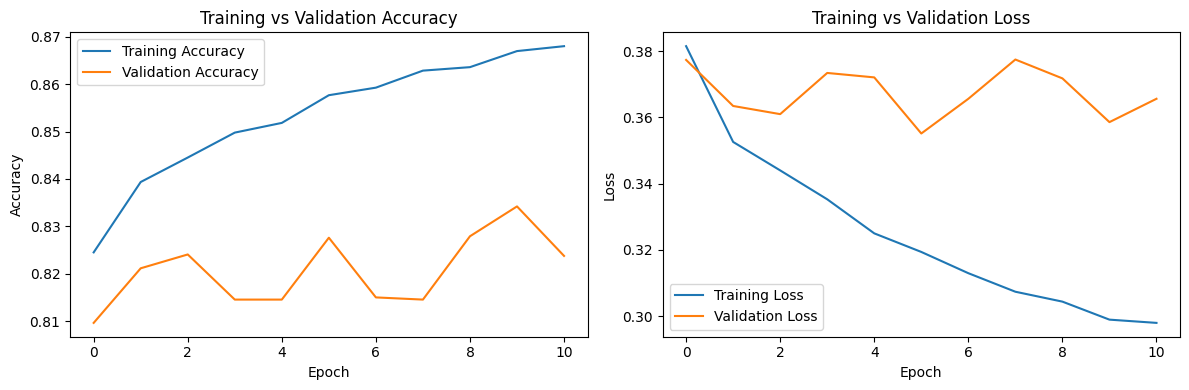

In [42]:
# ===============================
# TRAINING HISTORY VISUALIZATION
# ===============================

plt.figure(figsize=(12, 4))

# ---- Accuracy (KIRI) ----
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# ---- Loss (KANAN) ----
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()

# Simpan ke folder images (sejajar dengan notebook)
import os
parent_dir = os.path.dirname(os.getcwd())
images_path = os.path.join(parent_dir, 'images')
os.makedirs(images_path, exist_ok=True)
plt.savefig(os.path.join(images_path, "training_history_mlp.png"))

plt.show()


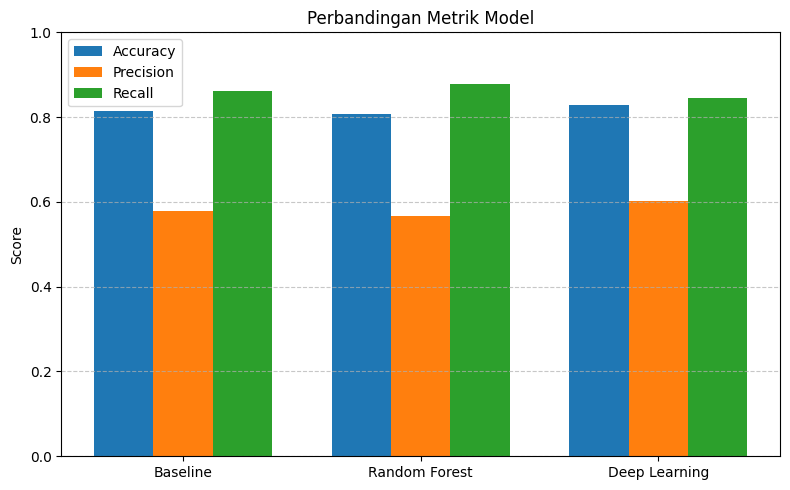

In [43]:
# Nama model
models = ['Baseline', 'Random Forest', 'Deep Learning']

# Nilai metrik (SESUIAI HASIL ANDA)
accuracy  = [0.8155, 0.8084, 0.8276]
precision = [0.5787, 0.5660, 0.6012]
recall    = [0.8610, 0.8776, 0.8450]

x = np.arange(len(models))
width = 0.25

plt.figure(figsize=(8, 5))

plt.bar(x - width, accuracy,  width, label='Accuracy')
plt.bar(x,         precision, width, label='Precision')
plt.bar(x + width, recall,    width, label='Recall')

plt.xticks(x, models)
plt.ylabel('Score')
plt.title('Perbandingan Metrik Model')
plt.ylim(0, 1)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()

# Simpan ke folder images (sejajar dengan notebook)
import os
parent_dir = os.path.dirname(os.getcwd())
images_path = os.path.join(parent_dir, 'images')
os.makedirs(images_path, exist_ok=True)
plt.savefig(os.path.join(images_path, "perbandingan_metrik_model.png"))

plt.show()
